# Linear Regression — Steel Industry Energy Consumption

We predict the energy use of a steel plant (`Usage_kWh`)
from operational covariates (reactive power, CO₂ emissions,
power factor, time of day, day of week, load type) using
ordinary least squares.

**Model:** $\hat{y} = w_0 + w_1 x_1 + \dots + w_p x_p$

**Loss:** $\;\mathrm{MSE}(w) = \tfrac{1}{n}\sum_i (y_i - \hat y_i)^2$

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rice_ml.processing.datasets import find_data_file

np.random.seed(0)
plt.rcParams["figure.figsize"] = (7, 4.5)

In [2]:
from rice_ml.supervised_learning.linear import LinearRegression
from rice_ml.processing.preprocessing import StandardScaler, train_test_split
from rice_ml.processing.metrics import root_mean_squared_error, r2_score, mean_absolute_error

df = pd.read_csv(find_data_file("Steel_industry_data.csv"))
df.head()

,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type
0,01/01/2018 00:15,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load
1,01/01/2018 00:30,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load
2,01/01/2018 00:45,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load
3,01/01/2018 01:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load
4,01/01/2018 01:15,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load


## Feature engineering

We extract simple time-of-day / day-of-week features from the
timestamp, then one-hot encode the categorical columns and
stack them with the numeric features.

In [3]:
df["date"] = pd.to_datetime(df["date"], format="%d/%m/%Y %H:%M")
df["hour"]  = df["date"].dt.hour
df["month"] = df["date"].dt.month

target = "Usage_kWh"
num_cols = [
    "Lagging_Current_Reactive.Power_kVarh",
    "Leading_Current_Reactive_Power_kVarh",
    "CO2(tCO2)",
    "Lagging_Current_Power_Factor",
    "Leading_Current_Power_Factor",
    "NSM", "hour", "month",
]
cat_cols = ["WeekStatus", "Day_of_week", "Load_Type"]

X_num = df[num_cols].to_numpy(dtype=float)
X_cat = pd.get_dummies(df[cat_cols], drop_first=True).to_numpy(dtype=float)
X = np.hstack([X_num, X_cat])
y = df[target].to_numpy(dtype=float)
print(f"X shape = {X.shape},  y range = [{y.min():.2f}, {y.max():.2f}]")

X shape = (35040, 17),  y range = [0.00, 157.18]


## Train and evaluate

In [4]:
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=0)
scaler = StandardScaler().fit(X_tr)
X_tr_s = scaler.transform(X_tr)
X_te_s = scaler.transform(X_te)

model = LinearRegression().fit(X_tr_s, y_tr)
y_pred = model.predict(X_te_s)

print(f"Test R^2  = {r2_score(y_te, y_pred):.4f}")
print(f"Test RMSE = {root_mean_squared_error(y_te, y_pred):.4f} kWh")
print(f"Test MAE  = {mean_absolute_error(y_te, y_pred):.4f} kWh")

Test R^2  = 0.9779
Test RMSE = 5.0084 kWh
Test MAE  = 2.6120 kWh


## Inspect the largest coefficients (on standardized inputs)

In [5]:
feat_names = num_cols + list(pd.get_dummies(df[cat_cols], drop_first=True).columns)
coefs = pd.Series(model.coef_, index=feat_names).sort_values(key=abs, ascending=False)
coefs.head(10).round(3)

CO2(tCO2)                               26.948
Lagging_Current_Reactive.Power_kVarh     4.939
Lagging_Current_Power_Factor             2.042
Leading_Current_Power_Factor             1.464
NSM                                     -1.274
hour                                     1.197
Load_Type_Medium_Load                    0.847
Load_Type_Maximum_Load                   0.592
month                                   -0.400
Leading_Current_Reactive_Power_kVarh     0.300
dtype: float64

## Residual diagnostic

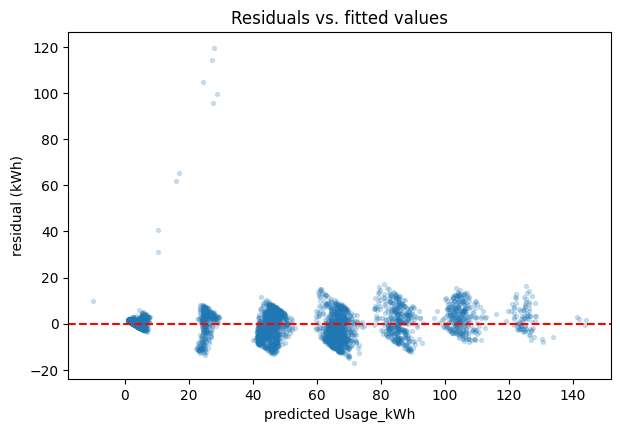

In [6]:
fig, ax = plt.subplots()
ax.scatter(y_pred, y_te - y_pred, alpha=0.2, s=8)
ax.axhline(0, color="red", linestyle="--")
ax.set_xlabel("predicted Usage_kWh")
ax.set_ylabel("residual (kWh)")
ax.set_title("Residuals vs. fitted values")
plt.show()

## Takeaways

- On standardized features, the lagging reactive power and
  CO₂ emissions are the dominant linear predictors of usage.
- The model captures most of the variance ($R^2 \gtrsim 0.9$),
  but the residual fan suggests Light/Medium/Maximum load
  types behave non-linearly — a tree-based model would close
  the remaining gap.